In [ ]:
!pip install ultralytics

import os
from ultralytics import YOLO

zip_file_name = "/content/yoda_odevlendirme_veriseti.yolov8.zip"
target_folder = "/content/dataset"

!unzip -q -o "$zip_file_name" -d "$target_folder"
content_yaml = """
path: /content/dataset
train: train/images
val: valid/images
test: test/images

nc: 4
names: ['blue_hexagon', 'blue_square', 'red_square', 'red_triangle']
"""

with open('/content/dataset/data.yaml', 'w') as dosya:
    dosya.write(content_yaml)

model = YOLO('yolov8s.pt')

model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='odev_result'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1c69f5d580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

Confusion Matrix:



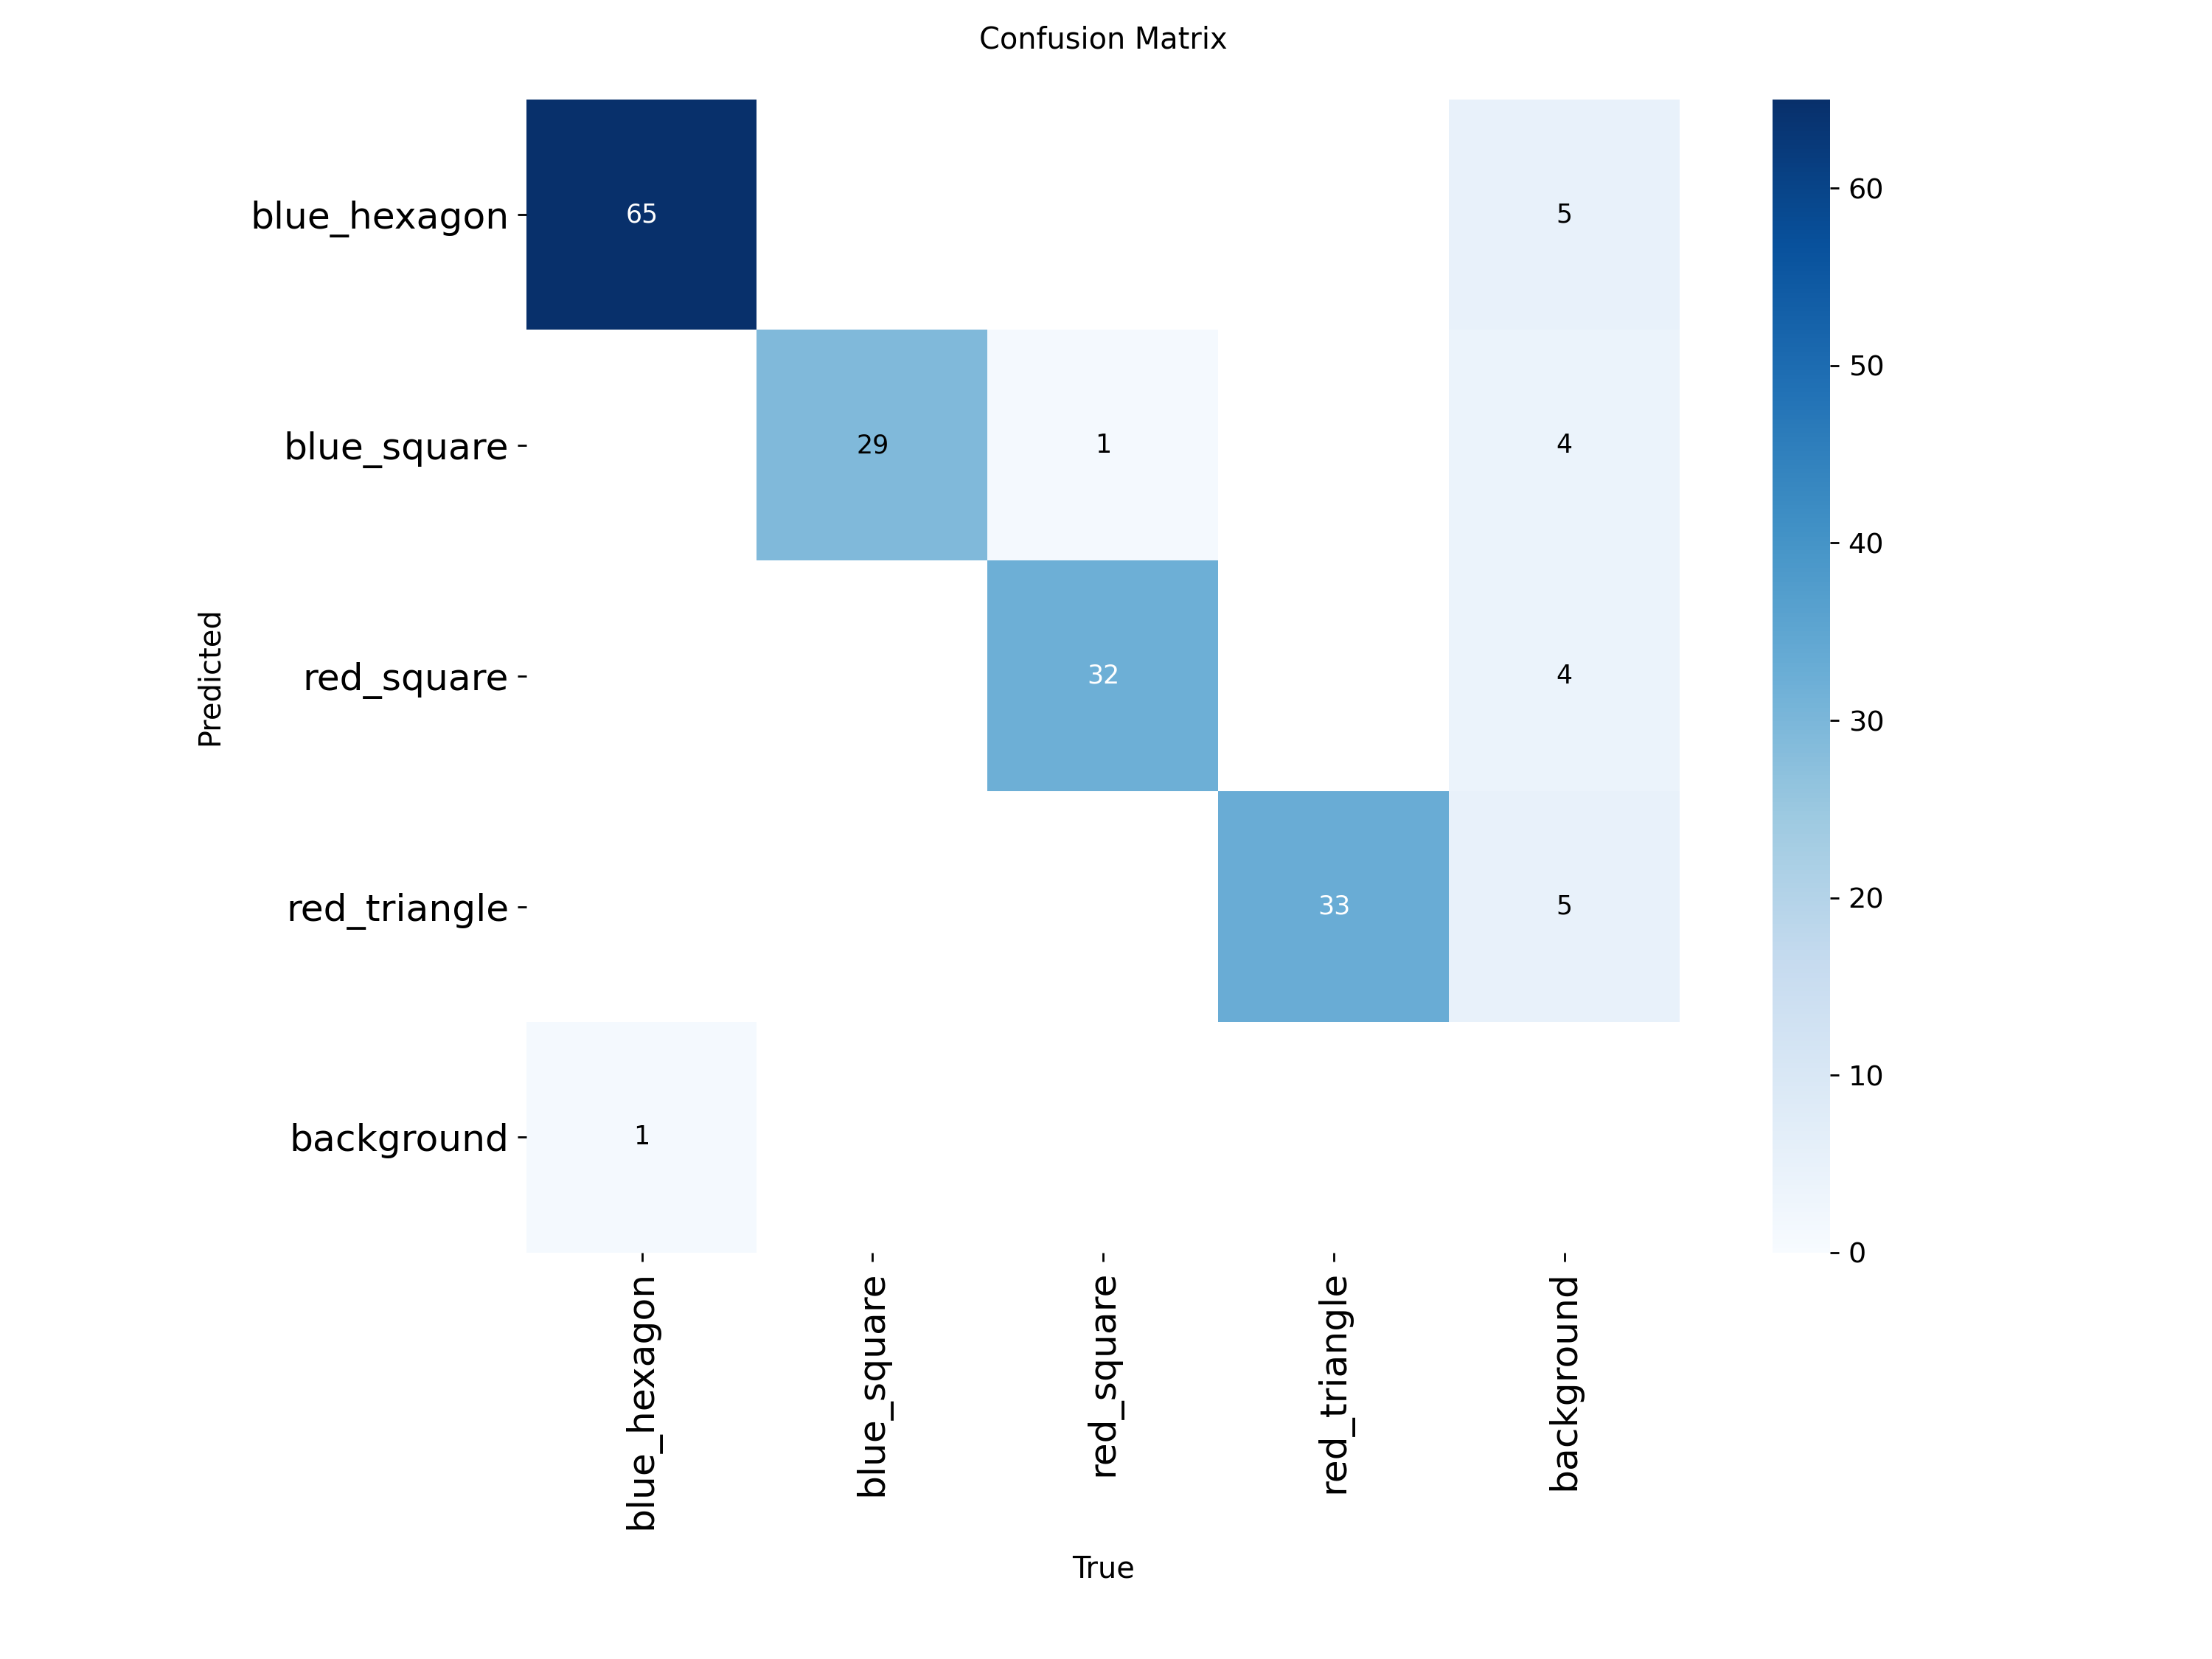

Loss and mAP Graphics:



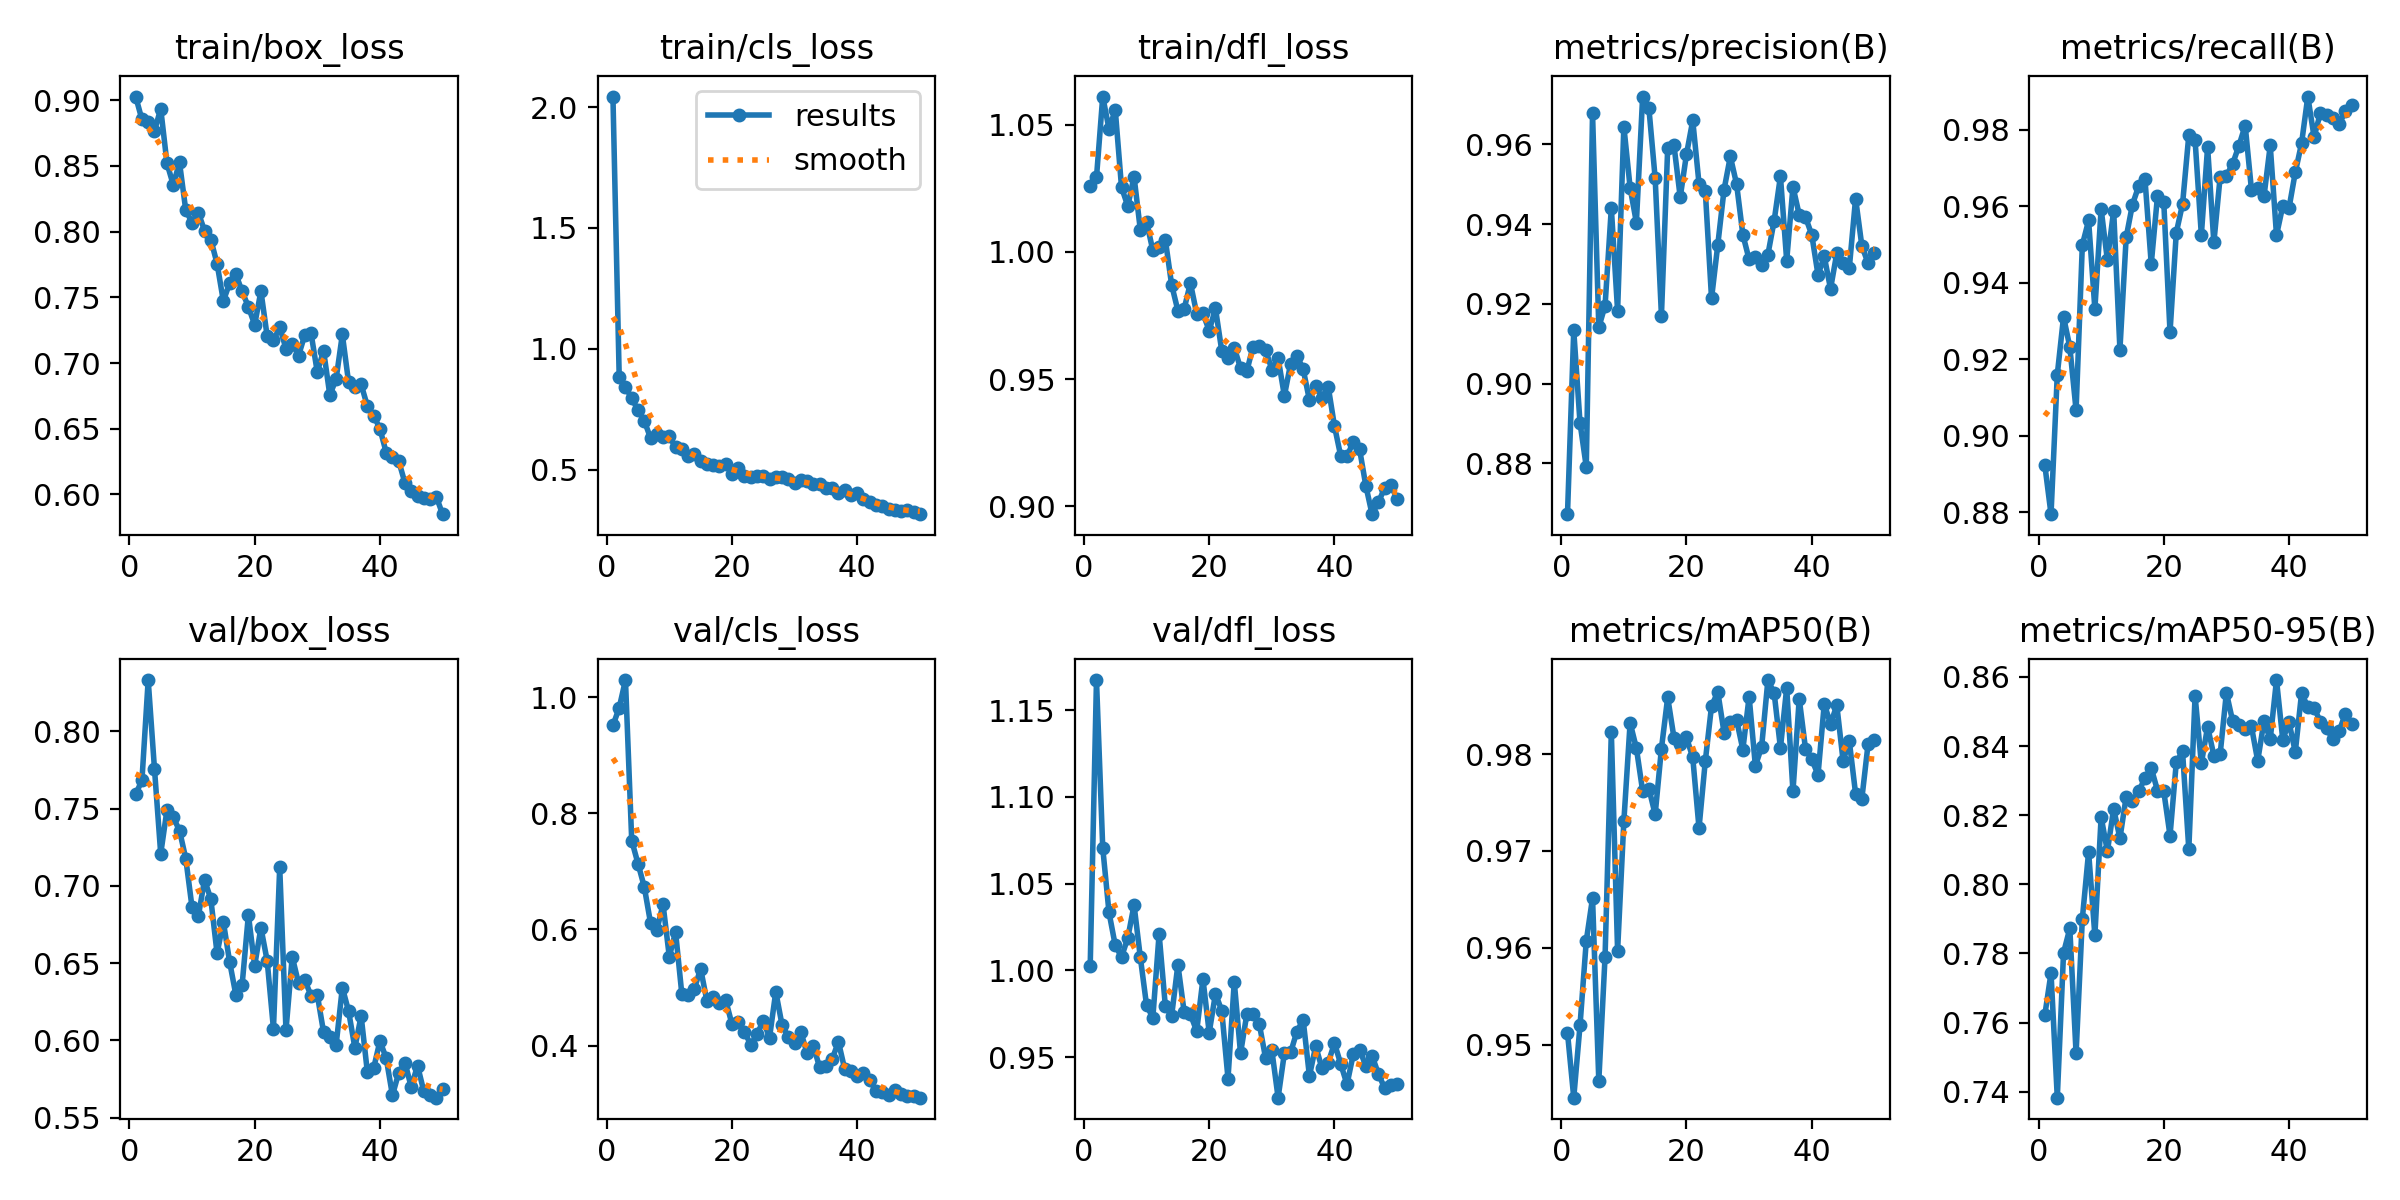

F1 Score:



FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/odev_result/PR_curve.png'

In [ ]:
from IPython.display import Image, display

result_folder = '/content/runs/detect/odev_result'

print("Confusion Matrix:\n")
display(Image(filename=f'{result_folder}/confusion_matrix.png'))

print("Loss and mAP Graphics:\n")
display(Image(filename=f'{result_folder}/results.png'))

print("F1 Score:\n")
display(Image(filename=f'{result_folder}/PR_curve.png'))

The Image is: frame_2025-09-03_19-45-15_0263_jpg.rf.2b499b32aa778f7b8287d03748a87f1f.jpg

image 1/1 /content/dataset/test/images/frame_2025-09-03_19-45-15_0263_jpg.rf.2b499b32aa778f7b8287d03748a87f1f.jpg: 640x640 1 red_triangle, 16.3ms
Speed: 2.0ms preprocess, 16.3ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)


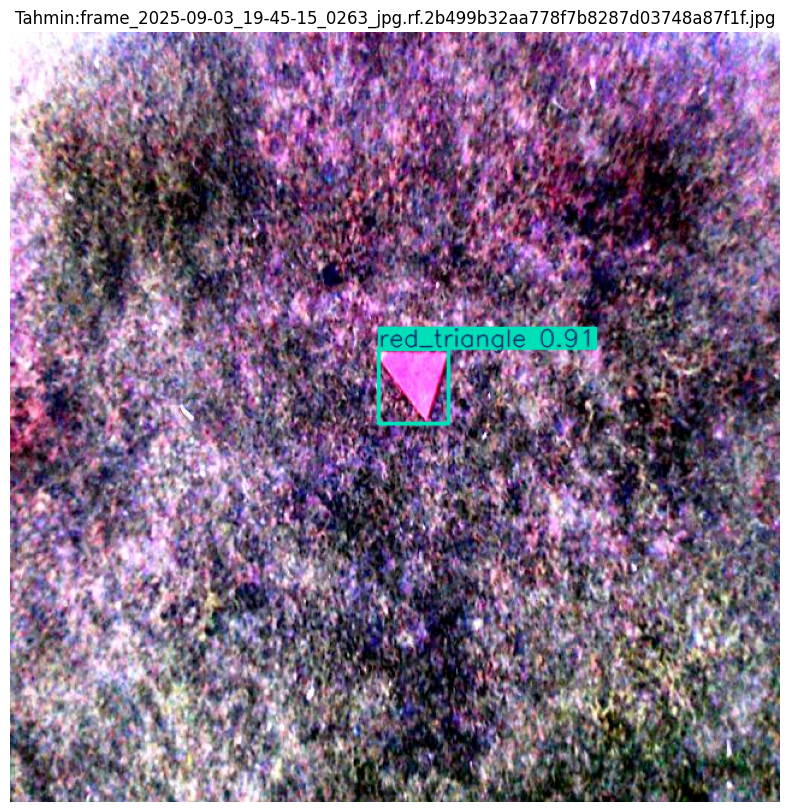

In [ ]:
import os
import random
import glob
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model_path = '/content/runs/detect/odev_result/weights/best.pt'
model = YOLO(model_path)
random_img = random.choice(os.listdir('/content/dataset/test/images'))
print(f"The Image is: {random_img}")
result = model.predict(source = f'/content/dataset/test/images/{random_img}', conf=0.5)

cizim = result[0].plot()
resim_rgb = cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (10,10))
plt.imshow(resim_rgb)
plt.axis('off')
plt.title(f"Tahmin:{random_img}")
plt.show()